# Working with HYCOM data

This notebook walks through common xarray operations on HYCOM output: slicing, regional masking, curvilinear plotting, time-based aggregations, and `groupby` for seasonal analysis.

We open the archive lazily with `chunks={"time": 1}` so the examples work on any size of archive without loading everything into memory.

In [ ]:
import xhycom

GRID_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
DATA_PATH = "/nird/datalake/NS9481K/shuang/TP2_output/expt_02.8/"

# Open the full archive lazily — no data read until .compute()
ds = xhycom.open_mfdataset(DATA_PATH + "archm.*", grid=GRID_PATH,
                            chunks={"time": 1})

## Physical units and derived fields

By default the data come back exactly as stored on disk, so some fields are in
HYCOM's native units — sea-surface height as geopotential, and layer thickness /
mixed-layer depth as pressure in Pa.  Pass `postprocess=True` to convert these to
physical units and add a few derived fields:

| Field | Native | `postprocess=True` |
|-------|--------|--------------------|
| `srfhgt` | geopotential (m² s⁻²) | sea-surface height in **m** (÷ g = 9.806) |
| `thknss`, `mix_dpth`, `bl_dpth`, `thmix` | pressure (Pa) | **m** (÷ onem = 9806) |
| `area` | — | `scpx · scpy` (m²), on grid files |
| `landmask` | — | 1 ocean / 0 land, from the bathymetry |

You can also apply it to an already-open dataset with `xhycom.postprocess(ds)`.

In [ ]:
# Same archive with native units converted + derived fields added.
# Kept on a separate handle so the rest of the notebook keeps the raw `ds`.
ds_pp = xhycom.open_mfdataset(DATA_PATH + "archm.*", grid=GRID_PATH,
                              chunks={"time": 1}, postprocess=True)

ds_pp["srfhgt"].attrs["units"], ds_pp["mix_dpth"].attrs["units"]

## Slicing

xarray's `isel` (index-based) and `sel` (label-based) selectors work directly.

In [12]:
# Surface temperature at the first time step
sst = ds["temp"].isel(time=0, k=0)

In [13]:
sst

<xarray.DataArray 'temp' (y: 380, x: 400)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(380, 400))
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    time     object 8B 2020-01-01 00:00:00
    k        int64 8B 1
    dens     float64 8B 0.1
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water potential temperature
    units:      degC

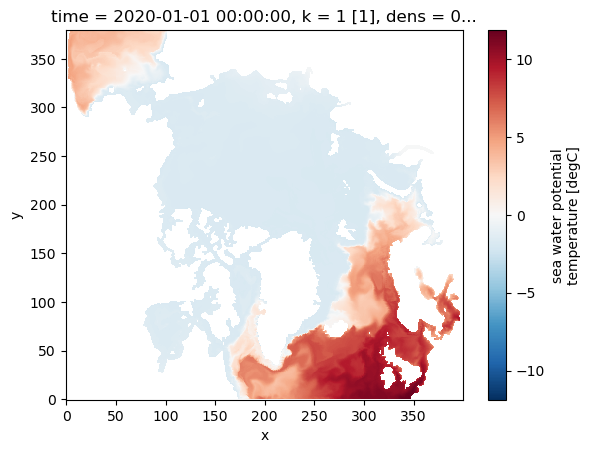

In [14]:
sst.plot()

In [15]:
temp_at_fixed_dens = ds["temp"].isel(time=0).isel(k=13)

In [16]:
temp_at_fixed_dens

<xarray.DataArray 'temp' (y: 380, x: 400)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(380, 400))
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    time     object 8B 2020-01-01 00:00:00
    k        int64 8B 14
    dens     float64 8B 26.9
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water potential temperature
    units:      degC

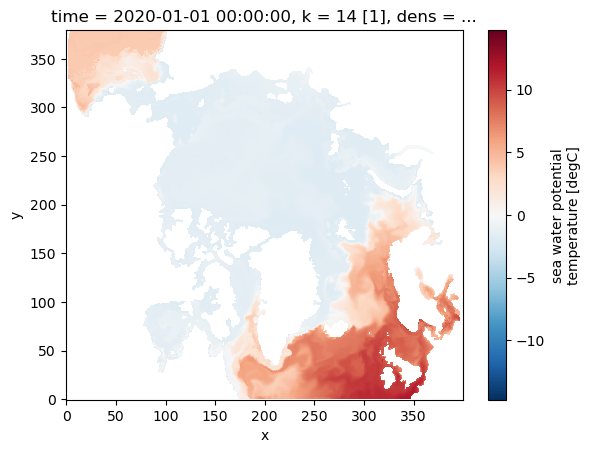

In [17]:
temp_at_fixed_dens.plot()

In [18]:
# Select by layer density instead of layer index
the_same_temp = ds["temp"].isel(time=0).sel(dens=27.0, method="nearest")

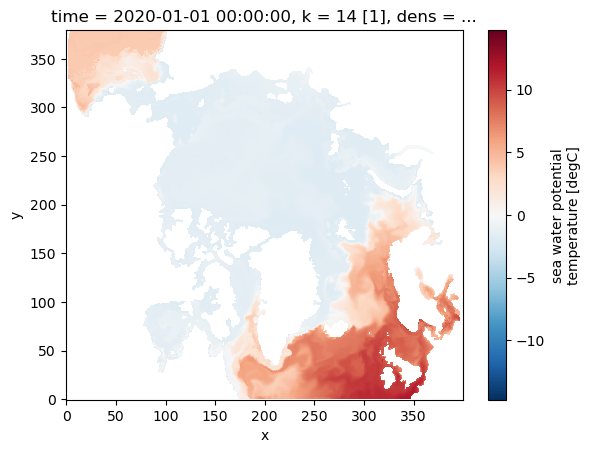

In [19]:
the_same_temp.plot()

## Regional analysis

HYCOM uses a curvilinear grid, so `lon` and `lat` are 2-D arrays — you cannot use `.sel(lon=..., lat=...)` for spatial subsetting.  Instead, build a boolean mask from the coordinate arrays and apply it with `.where()`.

In [ ]:
# Boolean mask: True inside the region, False outside
mask = (ds.lon > -30) & (ds.lon < 30) & (ds.lat > 50) & (ds.lat < 80)
mask.plot(cmap='RdYlGn');

Apply the mask to a variable — grid points outside the region become NaN:

In [ ]:
sst_region = ds['temp'].isel(k=0).where(mask)
sst_region.isel(time=0).plot(x='lon', y='lat');

With the mask applied, reductions like `.mean()` automatically ignore the masked-out (NaN) points.  Here we compute a time series of mean surface temperature inside the region:

In [ ]:
sst_ts = sst_region.mean(dim=['y', 'x']).compute()
sst_ts.plot()
import matplotlib.pyplot as plt
plt.ylabel('Mean SST (degC)')
plt.title('Regional mean surface temperature');

The same pattern works for any variable.  For example, sea-ice extent (fraction of the masked area with ice concentration above 15 %):

In [ ]:
ice_extent = (ds['covice'].where(mask) > 0.15).mean(dim=['y', 'x']).compute()
ice_extent.plot()
plt.ylabel('Ice extent fraction')
plt.title('Sea-ice extent in masked region (covice > 0.15);');

## Seasonal and monthly analysis with `groupby`

`groupby` splits the time axis by a label — calendar month, season, year — and applies a reduction.  Everything stays lazy until `.compute()` is called.

In [ ]:
# 4-season mean of surface temperature (reads all files on .compute())
sst_seasonal = ds["temp"].isel(k=0).groupby("time.season").mean()
sst_seasonal

In [ ]:
sst_seasonal.plot(col="season", col_wrap=2, x="lon", y="lat")

### March sea-ice concentration

Monthly groupby lets you compute a climatological mean for any specific month. Here we extract March (month 3) mean sea-ice concentration across all years.

In [ ]:
# Climatological March sea-ice concentration
ice_monthly = ds["covice"].groupby("time.month").mean()
march_ice = ice_monthly.sel(month=3)
march_ice

In [ ]:
march_ice.plot(x="lon", y="lat", cmap="Blues", vmin=0, vmax=1)

## Depth profiles

Select a point or average over a region, then plot along the vertical `k` dimension to inspect the T/S structure of the water column.

In [ ]:
# Time-mean temperature profile at a single grid point
temp_profile = ds['temp'].isel(y=150, x=200).mean('time').compute()
temp_profile.plot(y='k', yincrease=False)
import matplotlib.pyplot as plt
plt.xlabel('Temperature (degC)')
plt.ylabel('Layer index k')
plt.title('Time-mean temperature profile');

In [ ]:
# Overlay T and S on twin axes
sal_profile = ds['salin'].isel(y=150, x=200).mean('time').compute()

fig, ax1 = plt.subplots()
ax2 = ax1.twiny()
temp_profile.plot(y='k', yincrease=False, ax=ax1, color='tab:red',  label='T')
sal_profile.plot( y='k', yincrease=False, ax=ax2, color='tab:blue', label='S')
ax1.set_xlabel('Temperature (degC)', color='tab:red')
ax2.set_xlabel('Salinity (PSU)',      color='tab:blue')
ax1.set_ylabel('Layer index k')
plt.title('T–S profile');

## Hovmöller diagrams

A Hovmöller diagram shows how a variable evolves in time along one spatial axis.  Average out the other spatial dimension first.

In [ ]:
# Time × latitude Hovmöller of surface temperature
hovm = ds['temp'].isel(k=0).mean('x').compute()
hovm.plot(x='time', y='lat', cmap='RdYlBu_r')
plt.title('Surface temperature: time × latitude');

## Anomalies

Subtract the climatological monthly mean to isolate interannual or seasonal variability.

In [ ]:
# Climatological monthly mean
clim = ds['temp'].isel(k=0).groupby('time.month').mean()

# Anomaly: each time step minus its climatological month
anom = ds['temp'].isel(k=0).groupby('time.month') - clim

# Plot the anomaly for one time step
anom.isel(time=0).compute().plot(x='lon', y='lat',
                                  cmap='RdBu_r', center=0)
plt.title('SST anomaly (first time step)');

## Mixed layer depth

`mix_dpth` is stored in Pa — divide by ~9806 to convert to metres.  (With
`postprocess=True` this conversion is done for you, so `ds_pp["mix_dpth"]` is
already in metres and the manual `/ 9806.0` below is unnecessary.)

In [ ]:
# Mixed layer depth in metres, time series averaged over the domain
mld_m = (ds['mix_dpth'] / 9806.0).mean(dim=['y', 'x']).compute()
mld_m.attrs['units'] = 'm'
mld_m.plot()
plt.ylabel('Mixed layer depth (m)')
plt.gca().invert_yaxis()          # depth increases downward
plt.title('Domain-mean mixed layer depth');

## Saving a subset to NetCDF

Use `to_netcdf()` to write a subset of variables or time steps to a file for sharing or use with tools that do not read `.ab` format directly.

In [ ]:
# Write the top 10 layers of T and S for the first 12 time steps
subset = ds[['temp', 'salin']].isel(k=slice(0, 10), time=slice(0, 12))
subset.compute().to_netcdf('hycom_TS_top10_2020.nc')
print('Saved hycom_TS_top10_2020.nc')

## Plotting

In [23]:
sss = ds["salin"].isel(time=0, k=0)

For quick plots, use xarray's in-built plotting.


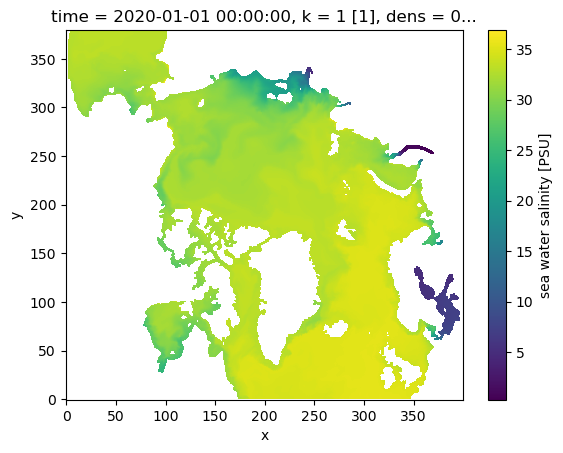

In [24]:
sss.plot()

Because `lon` and `lat` are 2-D curvilinear arrays, use `pcolormesh` directly rather than xarray's `.plot()`.  U-point and V-point variables carry `lon_u`/`lat_u` and `lon_v`/`lat_v` coordinates.

In [25]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [26]:
def ArcticMap():

    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw={"projection": ccrs.NorthPolarStereo(central_longitude=0.0)},
    )

    ax.set_extent([-180, 180, 48, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor=cfeature.COLORS["land"], edgecolor="grey", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="grey", linewidth=0.4, zorder=3)
    ax.gridlines()
      
    return fig, ax

In [27]:
def pcolormesh_curvilinear(lon, lat, data, ax=None, **kwargs):

    proj = ax.projection
    pxy = proj.transform_points(ccrs.PlateCarree(), lon, lat)
    px, py = pxy[:, :, 0], pxy[:, :, 1]
    invalid = ~np.isfinite(px) | ~np.isfinite(py)
    px = np.where(invalid, 0.0, px)
    py = np.where(invalid, 0.0, py)
    data = np.where(invalid, np.nan, data)
    return ax.pcolormesh(px, py, data, **kwargs)

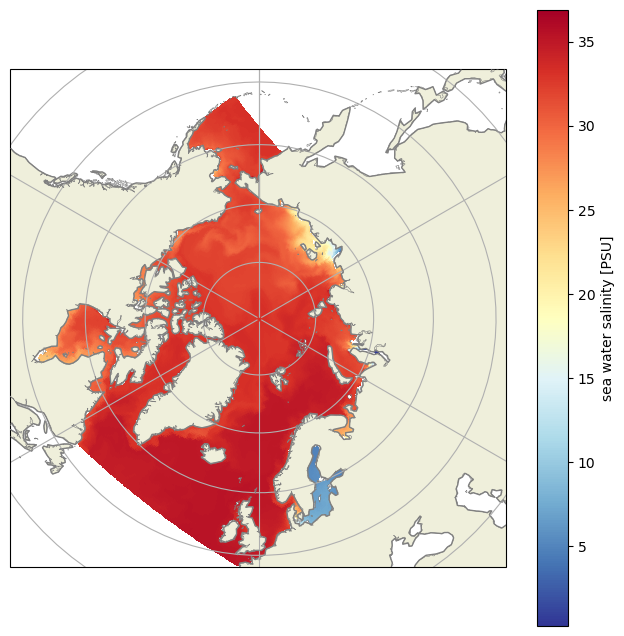

In [28]:
fig, ax = ArcticMap()
p = pcolormesh_curvilinear(sss.lon.values, sss.lat.values, sss.values, ax=ax, cmap="RdYlBu_r")
fig.colorbar(p, ax=ax, label=f"{sss.attrs['long_name']} [{sss.attrs['units']}]")

In [29]:
u = ds["u-vel."].isel(time=0, k=0)

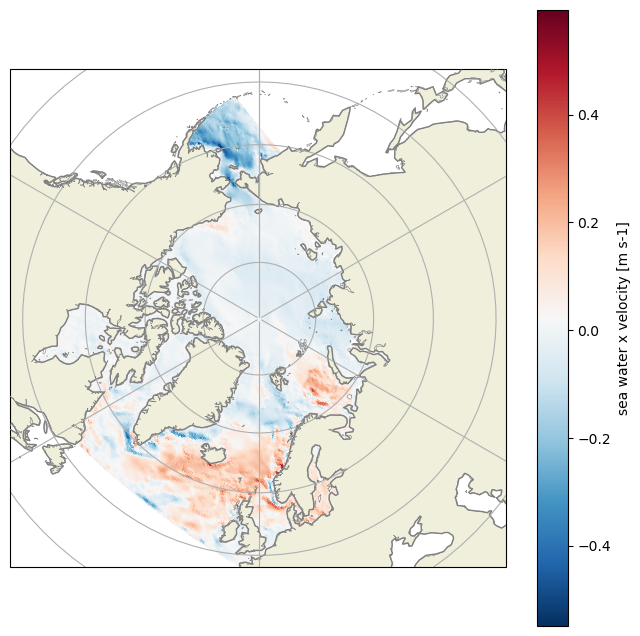

In [30]:
# U-point variable — use lon_u / lat_u

fig, ax = ArcticMap()
p = pcolormesh_curvilinear(u.lon_u.values, u.lat_u.values, u.values, ax=ax, cmap="RdBu_r")
fig.colorbar(p, ax=ax, label=f"{u.attrs['long_name']} [{u.attrs['units']}]")